In [97]:
# which factors are most strongly associated with Formula 1 driver performance?
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_columns', 200)


races = pd.read_csv('/content/f1_data/races.csv')
results = pd.read_csv('/content/f1_data/results.csv')
drivers = pd.read_csv('/content/f1_data/drivers.csv')
constructors = pd.read_csv('/content/f1_data/constructors.csv')
qualifying = pd.read_csv('/content/f1_data/qualifying.csv')


In [98]:
print(races.shape)
print(results.shape)
print(drivers.shape)
print(constructors.shape)
print(qualifying.shape)

(1125, 18)
(26759, 18)
(861, 9)
(212, 5)
(10494, 9)


In [99]:
print(races.columns)
print(results.columns)
print(drivers.columns)
print(constructors.columns)
print(qualifying.columns)

Index(['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url',
       'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time',
       'quali_date', 'quali_time', 'sprint_date', 'sprint_time'],
      dtype='object')
Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')
Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
       'nationality', 'url'],
      dtype='object')
Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object')
Index(['qualifyId', 'raceId', 'driverId', 'constructorId', 'number',
       'position', 'q1', 'q2', 'q3'],
      dtype='object')


In [100]:
df = results.copy()
print(df.columns)
print(df.shape)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='object')
(26759, 18)


In [101]:
df = df.merge(
    races[['raceId', 'year', 'round', 'name', 'date', 'circuitId']],
    on='raceId',
    how='left'
)

In [102]:
print(df.columns)
print(df.shape)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'name', 'date',
       'circuitId'],
      dtype='object')
(26759, 23)


In [103]:
df = df.merge(
    drivers[['driverId','driverRef', 'forename', 'surname', 'nationality' ]],
    on='driverId',
    how='left'

    )
print(df.columns)
print(df.shape)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'name', 'date',
       'circuitId', 'driverRef', 'forename', 'surname', 'nationality'],
      dtype='object')
(26759, 27)


In [104]:
df = df.merge(
    constructors[['constructorId', 'name', 'nationality']],
    on='constructorId',
    how='left',
    suffixes=('', '_constructor')
)
print(df.columns)
print(df.shape)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'name', 'date',
       'circuitId', 'driverRef', 'forename', 'surname', 'nationality',
       'name_constructor', 'nationality_constructor'],
      dtype='object')
(26759, 29)


In [105]:
qualifying_small = qualifying[
    ['raceId', 'driverId', 'position']
].rename(columns={
    'position': 'qualifyingPosition'
})

df = df.merge(
    qualifying_small,
    on=['raceId', 'driverId'],
    how='left'
)
print(df.columns)
print(df.shape)

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'year', 'round', 'name', 'date',
       'circuitId', 'driverRef', 'forename', 'surname', 'nationality',
       'name_constructor', 'nationality_constructor', 'qualifyingPosition'],
      dtype='object')
(26759, 30)


In [106]:
df.head(5)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,name,date,circuitId,driverRef,forename,surname,nationality,name_constructor,nationality_constructor,qualifyingPosition
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,1,Australian Grand Prix,2008-03-16,1,hamilton,Lewis,Hamilton,British,McLaren,British,1.0
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,1,Australian Grand Prix,2008-03-16,1,heidfeld,Nick,Heidfeld,German,BMW Sauber,German,5.0
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,1,Australian Grand Prix,2008-03-16,1,rosberg,Nico,Rosberg,German,Williams,British,7.0
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,1,Australian Grand Prix,2008-03-16,1,alonso,Fernando,Alonso,Spanish,Renault,French,12.0
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,1,Australian Grand Prix,2008-03-16,1,kovalainen,Heikki,Kovalainen,Finnish,McLaren,British,3.0


In [107]:
# Cleaning the dataset

df['driverName'] = df['forename'] + ' ' + df['surname']
df = df.drop(columns = ['forename', 'surname'], axis = 1)

In [108]:
df = df.replace(r'\N', np.nan)
df.isna().sum().sort_values(ascending=False)


,0
time,19079
milliseconds,19079
fastestLapSpeed,18507
fastestLapTime,18507
fastestLap,18507
rank,18249
qualifyingPosition,16265
position,10953
number,6
constructorId,0


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   resultId                 26759 non-null  int64  
 1   raceId                   26759 non-null  int64  
 2   driverId                 26759 non-null  int64  
 3   constructorId            26759 non-null  int64  
 4   number                   26753 non-null  object 
 5   grid                     26759 non-null  int64  
 6   position                 15806 non-null  object 
 7   positionText             26759 non-null  object 
 8   positionOrder            26759 non-null  int64  
 9   points                   26759 non-null  float64
 10  laps                     26759 non-null  int64  
 11  time                     7680 non-null   object 
 12  milliseconds             7680 non-null   object 
 13  fastestLap               8252 non-null   object 
 14  rank                  

In [110]:
df.describe()

,resultId,raceId,driverId,constructorId,grid,positionOrder,points,laps,statusId,year,round,circuitId,qualifyingPosition
count,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,26759.000000,10494.000000
mean,13380.977391,551.687283,278.673530,50.180537,11.134796,12.794051,1.987632,46.301768,17.224971,1991.394372,8.511192,23.820808,11.195826
std,7726.134642,313.265036,282.703039,61.551498,7.202860,7.665951,4.351209,29.496557,26.026104,19.952885,5.070231,19.112002,6.260374
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1950.000000,1.000000,1.000000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000,1977.000000,4.000000,9.000000,6.000000
50%,13380.000000,531.000000,172.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000,1991.000000,8.000000,18.000000,11.000000
75%,20069.500000,811.000000,399.500000,63.000000,17.000000,18.000000,2.000000,66.000000,14.000000,2009.000000,12.000000,34.000000,16.000000
max,26764.000000,1144.000000,862.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000,2024.000000,24.000000,80.000000,28.000000


In [111]:
df['position'] = pd.to_numeric(df['position'], errors='coerce')
df['fastestLap'] = pd.to_numeric(df['fastestLap'], errors='coerce')
df['rank'] = pd.to_numeric(df['rank'], errors='coerce')
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')

In [112]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   resultId                 26759 non-null  int64  
 1   raceId                   26759 non-null  int64  
 2   driverId                 26759 non-null  int64  
 3   constructorId            26759 non-null  int64  
 4   number                   26753 non-null  object 
 5   grid                     26759 non-null  int64  
 6   position                 15806 non-null  float64
 7   positionText             26759 non-null  object 
 8   positionOrder            26759 non-null  int64  
 9   points                   26759 non-null  float64
 10  laps                     26759 non-null  int64  
 11  time                     7680 non-null   object 
 12  milliseconds             7680 non-null   object 
 13  fastestLap               8252 non-null   float64
 14  rank                  

In [113]:
df['date'] = pd.to_datetime(df['date'])

df['milliseconds'] = pd.to_numeric(
    df['milliseconds'],
    errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   resultId                 26759 non-null  int64         
 1   raceId                   26759 non-null  int64         
 2   driverId                 26759 non-null  int64         
 3   constructorId            26759 non-null  int64         
 4   number                   26753 non-null  object        
 5   grid                     26759 non-null  int64         
 6   position                 15806 non-null  float64       
 7   positionText             26759 non-null  object        
 8   positionOrder            26759 non-null  int64         
 9   points                   26759 non-null  float64       
 10  laps                     26759 non-null  int64         
 11  time                     7680 non-null   object        
 12  milliseconds             7680 no

In [114]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
resultId,26759.0,13380.977391,1.0,6690.5,13380.0,20069.5,26764.0,7726.134642
raceId,26759.0,551.687283,1.0,300.0,531.0,811.0,1144.0,313.265036
driverId,26759.0,278.67353,1.0,57.0,172.0,399.5,862.0,282.703039
constructorId,26759.0,50.180537,1.0,6.0,25.0,63.0,215.0,61.551498
grid,26759.0,11.134796,0.0,5.0,11.0,17.0,34.0,7.20286
position,15806.0,8.020499,1.0,4.0,8.0,11.0,33.0,4.840796
positionOrder,26759.0,12.794051,1.0,6.0,12.0,18.0,39.0,7.665951
points,26759.0,1.987632,0.0,0.0,0.0,2.0,50.0,4.351209
laps,26759.0,46.301768,0.0,23.0,53.0,66.0,200.0,29.496557
milliseconds,7680.0,6185832.952865,526.0,5378454.5,5788193.5,6402676.0,15090540.0,1669306.488585


In [115]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [116]:
modern_df = df[df['year'] >= 2000].copy()

print(modern_df.shape)
print(modern_df['year'].value_counts().sort_index())

(10079, 29)
year
2000    373
2001    374
2002    362
2003    320
2004    360
2005    376
2006    396
2007    374
2008    368
2009    340
2010    456
2011    456
2012    480
2013    418
2014    407
2015    378
2016    462
2017    400
2018    420
2019    420
2020    340
2021    440
2022    440
2023    440
2024    479
Name: count, dtype: int64


In [117]:
modern_df.isna().sum().sort_values(ascending=False)

,0
time,5376
milliseconds,5376
position,2141
fastestLapTime,1827
fastestLap,1827
fastestLapSpeed,1827
rank,1569
qualifyingPosition,981
driverId,0
number,0


In [118]:
print("Exact duplicates:", modern_df.duplicated().sum())

Exact duplicates: 0


In [119]:
print(modern_df.shape)
print("Duplicates:", modern_df.duplicated().sum())

(10079, 29)
Duplicates: 0


In [120]:
# EDA of f1 data post 2000

grid_df = modern_df[
    modern_df['grid'] > 0
].copy()

print(grid_df.shape)

(9986, 29)


In [121]:
grid_corr = grid_df[
    ['grid', 'positionOrder']
].corr(method='spearman')

print(grid_corr)

                  grid  positionOrder
grid           1.00000        0.58625
positionOrder  0.58625        1.00000


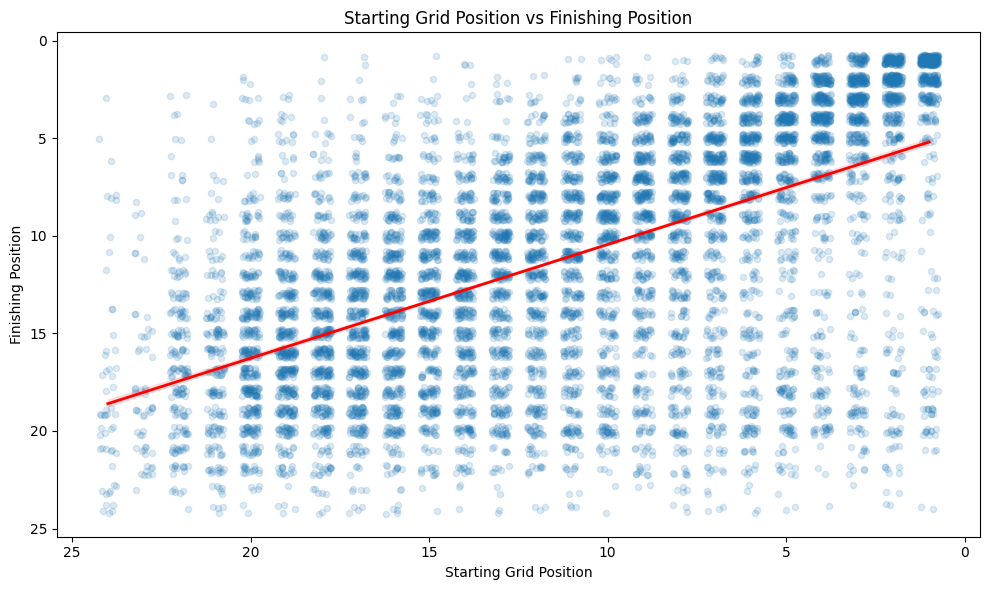

In [122]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=grid_df,
    x='grid',
    y='positionOrder',
    x_jitter=0.25,
    y_jitter=0.25,
    scatter_kws={'alpha': 0.15, 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.xlabel('Starting Grid Position')
plt.ylabel('Finishing Position')
plt.title('Starting Grid Position vs Finishing Position')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [123]:
constructor_performance = (
    modern_df
    .groupby('name_constructor')
    .agg(
        average_finish=('positionOrder', 'mean'),
        races=('raceId', 'count')
    )
    .sort_values('average_finish')
)

print(constructor_performance)

                  average_finish  races
name_constructor                       
Brawn                   4.882353     34
Mercedes                5.909836    610
Ferrari                 6.479123    958
Red Bull                7.347716    788
BMW Sauber              8.921429    140
McLaren                 8.981211    958
Renault                10.467626    556
Racing Point           10.631579     76
BAR                    10.916667    204
Aston Martin           11.155556    180
Alpine F1 Team         11.222222    180
Lotus F1               11.311688    154
Toyota                 11.450000    280
Force India            11.686321    424
Honda                  11.933962    106
Benetton               12.147059     68
Williams               12.330199    957
AlphaTauri             12.373494    166
Jaguar                 12.970588    170
Sauber                 13.186885    610
RB F1 Team             13.291667     48
Jordan                 13.365385    208
Alfa Romeo             13.384615    208


In [124]:
constructor_filtered = constructor_performance[
    constructor_performance['races'] >= 50
].reset_index()

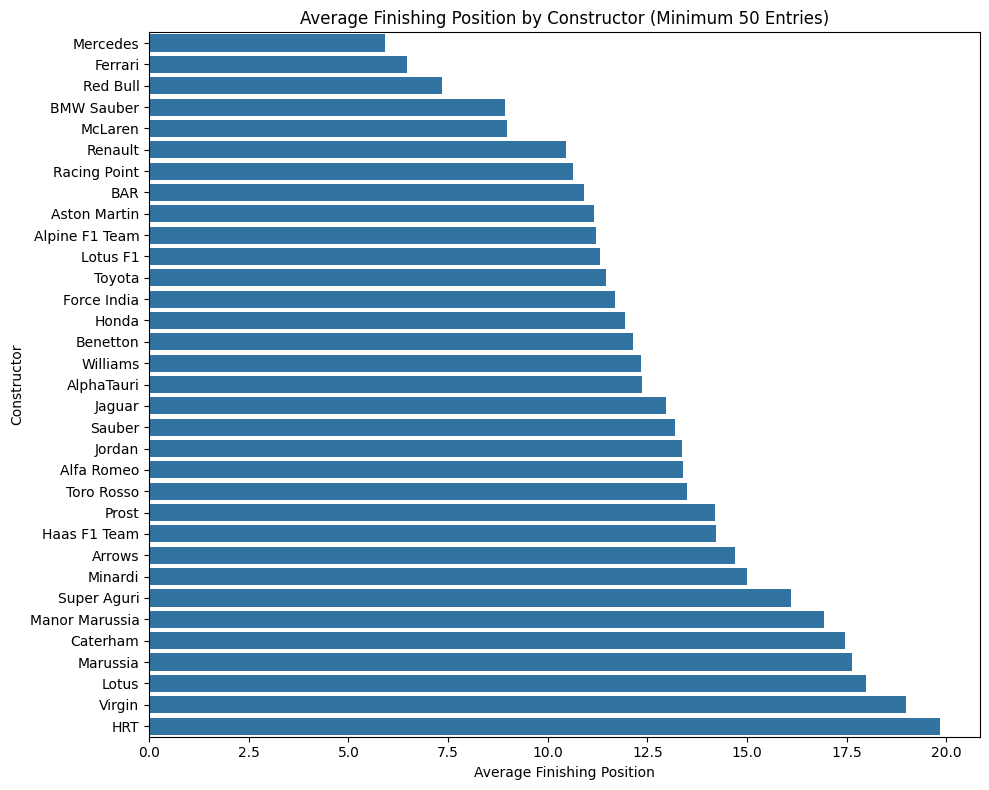

In [125]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=constructor_filtered,
    x='average_finish',
    y='name_constructor'
)

plt.xlabel('Average Finishing Position')
plt.ylabel('Constructor')
plt.title('Average Finishing Position by Constructor (Minimum 50 Entries)')

plt.tight_layout()
plt.show()

In [126]:
grid_df['positionsGained'] = (
    grid_df['grid'] - grid_df['positionOrder']
)

In [127]:
driver_performance = (
    grid_df
    .groupby('driverName')
    .agg(
        average_positions_gained=('positionsGained', 'mean'),
        entries=('raceId', 'count')
    )
    .sort_values('average_positions_gained', ascending=False)
)

print(driver_performance)

                       average_positions_gained  entries
driverName                                              
Tarso Marques                          7.384615       13
Gastón Mazzacane                       7.047619       21
Nicolas Kiesa                          6.600000        5
Alex Yoong                             5.800000       15
Marc Gené                              5.250000       20
...                                         ...      ...
Heinz-Harald Frentzen                 -1.850000       60
Ralf Schumacher                       -2.114504      131
Jarno Trulli                          -2.328571      210
Juan Pablo Montoya                    -3.157895       95
Mika Häkkinen                         -4.205882       34

[126 rows x 2 columns]


In [128]:
driver_filtered = (
    driver_performance[
        driver_performance['entries'] >= 50
    ]
    .reset_index()
)

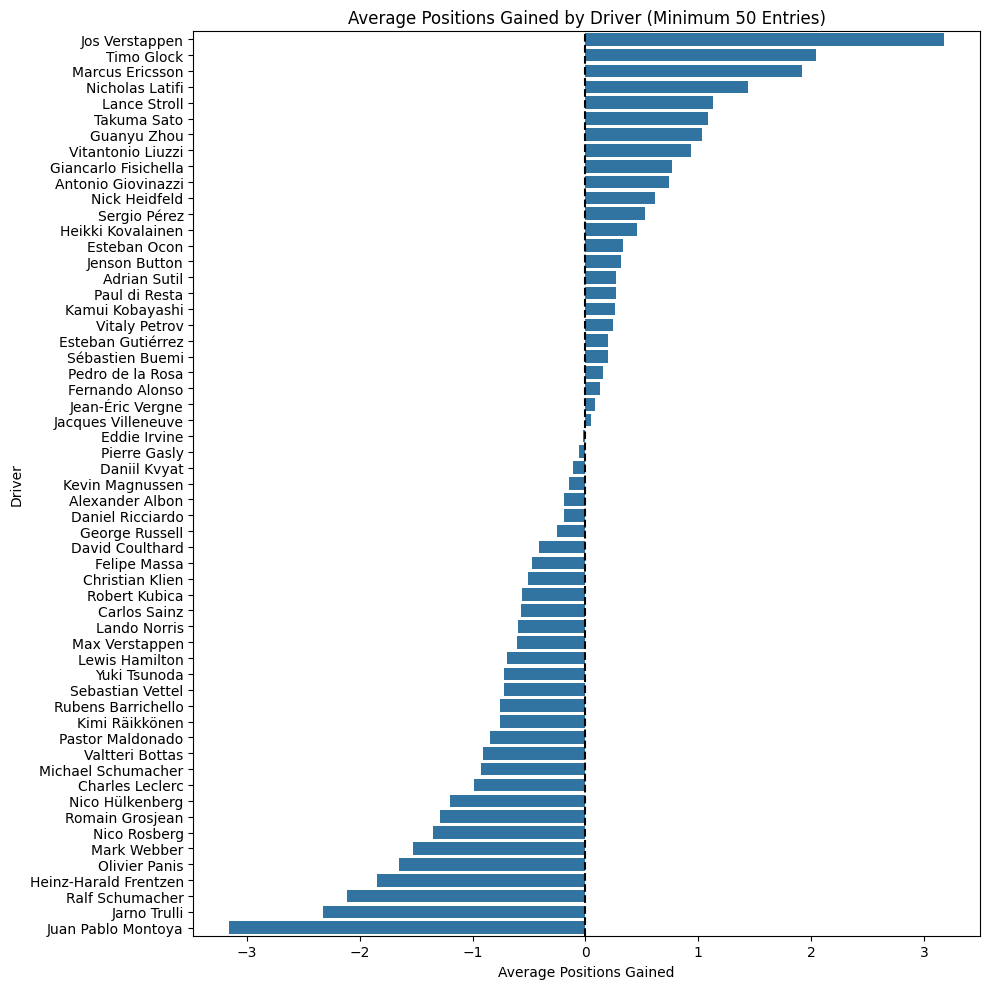

In [129]:
plt.figure(figsize=(10, 10))

sns.barplot(
    data=driver_filtered,
    x='average_positions_gained',
    y='driverName'
)

plt.axvline(0, color='black', linestyle='--')

plt.xlabel('Average Positions Gained')
plt.ylabel('Driver')
plt.title('Average Positions Gained by Driver (Minimum 50 Entries)')

plt.tight_layout()
plt.show()

In [130]:
pace_df = modern_df[
    (modern_df['rank'].notna()) &
    (modern_df['rank'] > 0)
].copy()

print(pace_df.shape)
pace_corr = pace_df[
    ['rank', 'positionOrder']
].corr(method='spearman')

print(pace_corr)

(8252, 29)
                   rank  positionOrder
rank           1.000000       0.743695
positionOrder  0.743695       1.000000


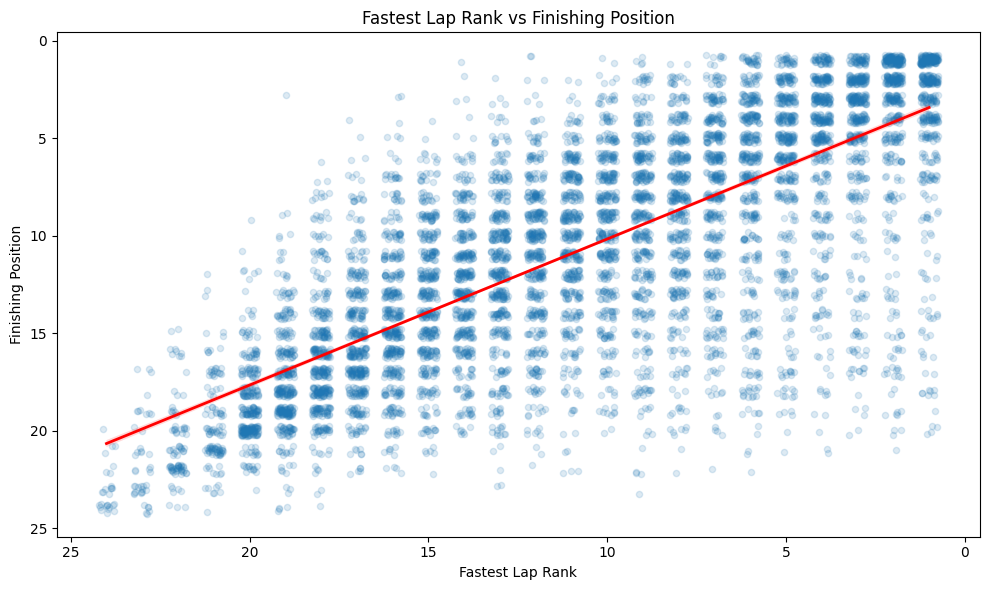

In [131]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=pace_df,
    x='rank',
    y='positionOrder',
    x_jitter=0.25,
    y_jitter=0.25,
    scatter_kws={'alpha': 0.15, 's': 20},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.xlabel('Fastest Lap Rank')
plt.ylabel('Finishing Position')
plt.title('Fastest Lap Rank vs Finishing Position')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [132]:
grid_model_df = modern_df[
    modern_df['grid'] > 0
][['grid', 'positionOrder']].dropna().copy()

print(grid_model_df.shape)

(9986, 2)


In [133]:
X = grid_model_df[['grid']]
y = grid_model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

grid_model = LinearRegression()

grid_model.fit(X_train, y_train)

grid_pred = grid_model.predict(X_test)

grid_r2 = r2_score(y_test, grid_pred)
grid_mae = mean_absolute_error(y_test, grid_pred)

print("Grid R²:", grid_r2)
print("Grid MAE:", grid_mae)

Grid R²: 0.30692097640898175
Grid MAE: 4.010300012454883


In [134]:
lap_model_df = modern_df[
    modern_df['rank'] > 0
][['rank', 'positionOrder']].dropna().copy()

print(lap_model_df.shape)

X = lap_model_df[['rank']]
y = lap_model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lap_model = LinearRegression()

lap_model.fit(X_train, y_train)

lap_pred = lap_model.predict(X_test)

lap_r2 = r2_score(y_test, lap_pred)
lap_mae = mean_absolute_error(y_test, lap_pred)

print("Lap Rank R²:", lap_r2)
print("Lap Rank MAE:", lap_mae)

(8252, 2)
Lap Rank R²: 0.5803281015850075
Lap Rank MAE: 2.9998260141395603


In [135]:
constructor_model_df = modern_df[
    ['name_constructor', 'positionOrder']
].dropna().copy()

X = pd.get_dummies(
    constructor_model_df[['name_constructor']],
    drop_first=True
)

y = constructor_model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

constructor_model = LinearRegression()
constructor_model.fit(X_train, y_train)

constructor_pred = constructor_model.predict(X_test)

constructor_r2 = r2_score(y_test, constructor_pred)
constructor_mae = mean_absolute_error(y_test, constructor_pred)

print("Constructor R²:", constructor_r2)
print("Constructor MAE:", constructor_mae)

Constructor R²: 0.239945507073842
Constructor MAE: 4.3468346094230075


In [136]:
driver_model_df = modern_df[
    ['driverName', 'positionOrder']
].dropna().copy()

X = pd.get_dummies(
    driver_model_df[['driverName']],
    drop_first=True
)

y = driver_model_df['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

driver_model = LinearRegression()
driver_model.fit(X_train, y_train)

driver_pred = driver_model.predict(X_test)

driver_r2 = r2_score(y_test, driver_pred)
driver_mae = mean_absolute_error(y_test, driver_pred)

print("Driver R²:", driver_r2)
print("Driver MAE:", driver_mae)

Driver R²: 0.2279400030333132
Driver MAE: 4.407179014209465


In [137]:
factor_results = pd.DataFrame({
    'Factor': [
        'Starting Grid',
        'Fastest Lap Rank',
        'Constructor',
        'Driver'
    ],
    'R2': [
        grid_r2,
        lap_r2,
        constructor_r2,
        driver_r2
    ],
    'MAE': [
        grid_mae,
        lap_mae,
        constructor_mae,
        driver_mae
    ]
})

factor_results = factor_results.sort_values(
    'R2',
    ascending=False
)

print(factor_results)

             Factor        R2       MAE
1  Fastest Lap Rank  0.580328  2.999826
0     Starting Grid  0.306921  4.010300
2       Constructor  0.239946  4.346835
3            Driver  0.227940  4.407179


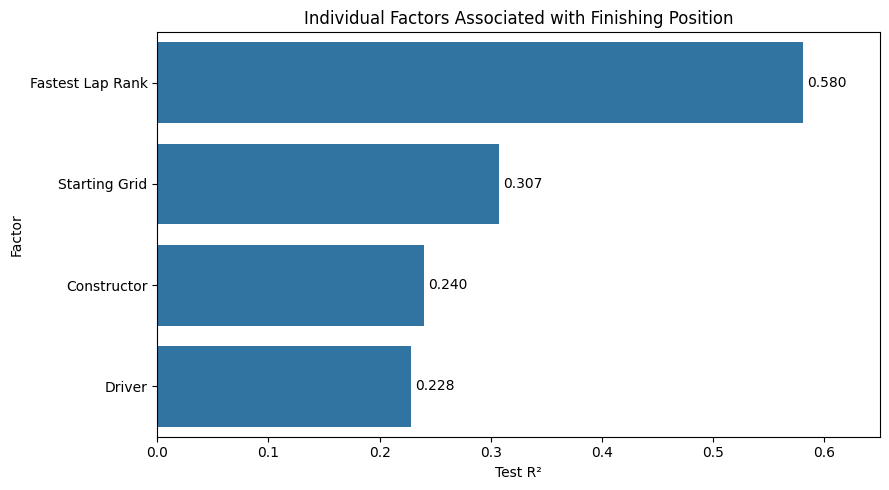

In [138]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=factor_results,
    x='R2',
    y='Factor'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.xlabel('Test R²')
plt.ylabel('Factor')
plt.title('Individual Factors Associated with Finishing Position')

plt.xlim(0, 0.65)
plt.tight_layout()
plt.show()

# Results
The exploratory data analysis showed clear relationships between different factors and the finishing position. The first factor was starting position and we saw the starting position had a positive correlation with the finishing position of a driver. Showing that drivers starting near the front of the grid also finish near the front. It also shows that drivers starting in first place lose positions on average because they cannot gain any and the opposite is true for drivers that start last. The grid only regression supports this relationship with R^2 of 0.307 and MAE of 4.01.

The fastest-lap rank had an even stronger correlation with the finishing position. The Spearman rank correlation between fastest-lap rank and finishing position was 0.744 which shows a strong positive correlation.The individual regression model supported this finding, producing the highest test R^2 of the four factors at 0.580, with an MAE of approximately 3.00 positions. However, fastest-lap rank is recorded during the race and is itself an indicator of race pace, so this relationship should not be interpreted as evidence that a better fastest lap causes a better finishing position.

The constructor analysis also showed differences in the finishing positions between different teams. Some constructors had a much better average finishing position than others, showing that the team a driver races for is associated with their performance. Constructors with less than 50 race entries were removed so that teams with a very small number of races did not have a large effect on the results. The constructor-only regression had an R^2 of 0.240 and an MAE of 4.35 positions. This shows that constructor was associated with finishing position, but the model was less informative than starting grid position and fastest-lap rank.


The driver analysis also showed differences in performance between drivers. We looked at the average number of positions gained by each driver and found that some drivers gained more positions on average than others. However, this measure is affected by where a driver starts the race. A driver starting near the back has more positions available to gain, while a driver starting near the front has fewer positions they can gain.

The driver-only regression had an R^2 of 0.228 and an MAE of 4.41 positions. This was the lowest R^2 of the four models, although this does not mean that driver skill is the least important factor because driver identity does not directly measure the skill of a driver.

Overall, the EDA and regression models showed that all four factors had some relationship with finishing position. Fastest-lap rank had the highest R^2 of 0.580, followed by starting grid position at 0.307, constructor at 0.240 and driver at 0.228. This suggests that fastest-lap rank was the most informative individual factor out of the four factors analysed, while driver identity was the least informative on its own. These results show associations between the factors and finishing position and do not prove that any of these factors directly cause a driver to finish in a certain position.

# Limitations
Fastest-lap rank is recorded during a race and is therefore itself an
indicator of race performance. Driver and constructor are also
categorical variables and do not directly measure driver skill or car
performance.
